# 04 — Virtual lesioning atlas (extension, Part A)

## Motivation

In Notebook 03 we reproduced Alexandersen et al. (2025): gliomas drive elevated
whole-brain coupling, and masking out the tumour regions (Section 9) reduces
the fit to the patient PLI more than it reduces the fit to the control PLI.
That result tells us *that* tumour regions matter, but not *why* those specific
regions matter.

In this notebook we **generalise Section 9 from 3–4 predefined tumour sets to
every one of the 78 AAL regions**, producing a map of "coupling drivers" — the
regions whose functional signature is most critical for fitting the empirical
data. We then ask whether these drivers coincide with structural hubs and with
the tumour locations used in the paper.

This is the first half of our extension. Part B (Notebook 05) will take the
top drivers identified here and physically damage their structural connections
in the SC matrix, testing whether anatomical disruption alone is enough to
reproduce the glioma-like coupling signature.

## Hypothesis

**H1.** Lesioning hub regions (high structural degree/strength/eigenvector
centrality) will produce larger shifts in the optimal coupling parameter
`K*` than lesioning peripheral regions. Equivalently, there should be a
**positive rank correlation** between a region's structural importance and
its virtual-lesioning effect size.

**H3.** The top coupling drivers identified by virtual lesioning should
overlap significantly with the tumour regions used in Alexandersen et al.
(Frontal L/R + Temporal L, 19 regions total). If they do, the paper's
connectotomy result is a consequence of the structural importance of those
regions, not a tumour-specific phenomenon.

## Methodology

For every region `i in 1..78`, for every initial condition `ic`:

1. Sweep `K` over a dense grid at fixed `λ = 40` (the best-fit λ from
   Notebook 03). Only **one simulation** is needed per `(ic, K)` point —
   the 78 masked correlations are cheap post-processing on the resulting
   PLI matrix.
2. From the `K`-sweep extract `K*_full` (argmax of full correlation) and
   `K*_lesion_i` (argmax of the correlation computed after masking out row
   and column `i`). The lesioning effect for region `i` is
   `ΔK_i = K*_lesion_i − K*_full`.
3. Repeat against both control and glioma empirical PLI; the difference
   `ΔK_i^glioma − ΔK_i^control` isolates region-specific effects that are
   stronger in the patient cohort.
4. Aggregate across ICs to get a mean + 95% CI + Wilcoxon p-value per
   region, per cohort.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.stats import spearmanr

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "project_paths.py").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from project_paths import figures_dir, find_project_root
from results_io import load_validated_npz
from network_analysis import (
    AAL78_LABELS,
    NETWORK_NAMES,
    NETWORK_COLORS,
    fit_virtual_lesion_one_ic,
    load_cortical_frequencies,
    matrix_correlation,
    normalize_weights,
    overlap_test,
    plot_labelled_matrix,
    structural_hubness,
    summarise_delta_k,
    top_k_drivers,
    upper_triangle_values,
)

ROOT = find_project_root(ROOT)
FIG_DIR = figures_dir("virtual lesioning", root=ROOT)

N_JOBS = int(os.environ.get("HOPF_N_JOBS", "-1"))

%matplotlib inline
plt.rcParams.update({"figure.dpi": 300, "font.size": 11})
RNG = np.random.default_rng(11)

print(f"Parallel workers: N_JOBS={N_JOBS}")
print(f"Figures: {FIG_DIR}")


Parallel workers: N_JOBS=-1
Figures: C:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\figures\hopf model\virtual lesioning


## 1. Load empirical data

Same pipeline as Notebook 03 — structural connectivity (spectral-normalised),
raw control + glioma PLI, and subject-mean peak cortical frequencies.

In [2]:
SC_EMP = normalize_weights(
    np.loadtxt(ROOT / "data" / "structural_connectivity_matrix.csv", delimiter=","),
    method="spectral",
)
CONTROL_PLI = np.loadtxt(ROOT / "data" / "control_PLI_raw.csv", delimiter=",")
GLIOMA_PLI  = np.loadtxt(ROOT / "data" / "glioma_PLI_raw.csv",  delimiter=",")
CORTICAL_FREQ = load_cortical_frequencies(ROOT / "data" / "exp_frequencies.csv")

N_REGIONS = SC_EMP.shape[0]

print(f"SC: {SC_EMP.shape}")
print(f"Control PLI: {CONTROL_PLI.shape}, Glioma PLI: {GLIOMA_PLI.shape}")
print(f"Cortical frequencies: {CORTICAL_FREQ.shape} "
      f"(range {CORTICAL_FREQ.min():.1f}–{CORTICAL_FREQ.max():.1f} Hz)")

SC: (78, 78)
Control PLI: (78, 78), Glioma PLI: (78, 78)
Cortical frequencies: (78,) (range 6.2–10.9 Hz)


## 2. Structural hubness baseline

Before running any simulations, we quantify each region's structural
importance using three graph-theoretic measures on the SC matrix:

- **Degree**: number of non-zero edges (count-based hubness).
- **Strength**: sum of absolute edge weights (weight-based hubness).
- **Eigenvector centrality**: recursive definition — a region is
  central if it connects to other central regions (global hubness).

These are what we will correlate against the virtual-lesioning ΔK to test H1.

In [3]:
HUBNESS = structural_hubness(SC_EMP)

print("Top-10 hubs by strength:")
order = np.argsort(HUBNESS["strength"])[::-1]
for rank, r in enumerate(order[:10], 1):
    print(f"  {rank:2d}. {AAL78_LABELS[r]:<22s}  "
          f"strength={HUBNESS['strength'][r]:.3f}  "
          f"degree={HUBNESS['degree'][r]:3d}  "
          f"eigcent={HUBNESS['eigcent'][r]:.3f}")


Top-10 hubs by strength:
   1. Frontal Mid L           strength=1.775  degree= 27  eigcent=0.381
   2. ParaHippocampal L       strength=1.595  degree= 32  eigcent=0.325
   3. Amygdala R              strength=1.590  degree= 26  eigcent=0.364
   4. Frontal Inf Orb R       strength=1.471  degree= 22  eigcent=0.279
   5. Occipital Inf L         strength=1.459  degree= 17  eigcent=0.003
   6. Parietal Inf R          strength=1.431  degree= 19  eigcent=0.003
   7. Rolandic Oper R         strength=1.353  degree= 21  eigcent=0.208
   8. Frontal Inf Tri R       strength=1.223  degree= 23  eigcent=0.315
   9. Parietal Sup R          strength=1.194  degree= 18  eigcent=0.003
  10. Frontal Mid R           strength=1.110  degree= 19  eigcent=0.300


## 3. Virtual-lesioning sweep

For each initial condition we sweep `K` over a 60-point grid at fixed
`λ = 40`. Per `(ic, K)` we simulate once and then compute 79 correlations
per cohort (1 full + 78 single-region masked). `argmax` over `K` yields
`K*_full` and 78 values of `K*_lesion_i`.

**Compute budget**: 300 ICs × 60 K values = 18,000 simulations. At
~75 ms/sim under the Notebook 03 `GRID_SIM_KW` settings this takes
~25–40 min on 16 cores.

In [4]:
# Simulation + sweep parameters
VLA_LAM = 40                               # best-fit λ from Notebook 03
VLA_K   = np.linspace(0.5, 50, 60)         # 60 K values, 0.5 → 50
VLA_N_IC = 300                             # 300 ICs for tight CIs
VLA_SIM_KW = dict(t_total=8.0, t_discard=1.5, fs=300)   # matches Notebook 03 GRID_SIM_KW

print(f"Virtual-lesioning sweep:")
print(f"  λ        = {VLA_LAM}")
print(f"  K grid   = {len(VLA_K)} values from {VLA_K.min():.1f} to {VLA_K.max():.1f}")
print(f"  ICs      = {VLA_N_IC}")
print(f"  total    = {VLA_N_IC * len(VLA_K):,} sims")

Virtual-lesioning sweep:
  λ        = 40
  K grid   = 60 values from 0.5 to 50.0
  ICs      = 300
  total    = 18,000 sims


In [5]:
_cache_path = ROOT / "data" / "vla_results.npz"
_use_cache = False

if _cache_path.exists():
    _cache = load_validated_npz(_cache_path)
    _cache_lam = float(np.atleast_1d(_cache["VLA_LAM"])[0])
    _cache_matches = (
        np.array_equal(_cache["VLA_K"], VLA_K)
        and np.isclose(_cache_lam, VLA_LAM)
        and _cache["dK_ctrl"].shape == (VLA_N_IC, N_REGIONS)
        and _cache["dK_glio"].shape == (VLA_N_IC, N_REGIONS)
        and _cache["dK_diff"].shape == (VLA_N_IC, N_REGIONS)
    )
    if _cache_matches:
        dK_ctrl = _cache["dK_ctrl"]
        dK_glio = _cache["dK_glio"]
        dK_diff = _cache["dK_diff"]
        Kfull_ctrl = _cache["Kfull_ctrl"]
        Kfull_glio = _cache["Kfull_glio"]
        _use_cache = True
        print(f"Rehydrated virtual-lesioning results from {_cache_path}")
        print(f"  dK_ctrl: {dK_ctrl.shape}   dK_glio: {dK_glio.shape}")
        print(f"  K grid : {VLA_K.shape}, lambda={VLA_LAM}, ICs={VLA_N_IC}")
    else:
        print("VLA cache settings differ from this notebook; recomputing.")

if not _use_cache:
    print("Running virtual-lesioning sweep ...")
    vla_results = Parallel(n_jobs=N_JOBS, verbose=2)(
        delayed(fit_virtual_lesion_one_ic)(
            ic, VLA_LAM, VLA_K, SC_EMP, CORTICAL_FREQ,
            CONTROL_PLI, GLIOMA_PLI, VLA_SIM_KW,
        )
        for ic in range(VLA_N_IC)
    )

    vla_results.sort(key=lambda r: r[0])
    Kfull_ctrl = np.array([r[1] for r in vla_results])
    Kfull_glio = np.array([r[2] for r in vla_results])
    Kmask_ctrl = np.stack([r[3] for r in vla_results], axis=0)
    Kmask_glio = np.stack([r[4] for r in vla_results], axis=0)

    dK_ctrl = Kmask_ctrl - Kfull_ctrl[:, None]
    dK_glio = Kmask_glio - Kfull_glio[:, None]
    dK_diff = dK_glio - dK_ctrl

    print()
    print(f"Sweep complete: Kfull_ctrl mean={Kfull_ctrl.mean():.2f}, "
          f"Kfull_glio mean={Kfull_glio.mean():.2f}")


Running virtual-lesioning sweep ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


KeyboardInterrupt: 

## 4. Per-region summaries

For each region we compute the mean ΔK (glioma and control), a 95% bootstrap
CI, and a Wilcoxon signed-rank p-value testing whether ΔK differs from zero.

Interpretation:
- `dK_ctrl[i]` < 0 means hiding region `i` from the control fit *reduces*
  the optimal `K*` — so region `i` was helping drive coupling upward in the
  control match.
- `dK_glio[i]` < 0 means the same for the glioma fit.
- `dK_diff[i]` = `dK_glio[i] − dK_ctrl[i]`: positive values mean the region
  contributes *more* to glioma's elevated coupling than to the control fit —
  these are the **glioma-specific drivers**.

In [ ]:
sum_ctrl = summarise_delta_k(dK_ctrl)
sum_glio = summarise_delta_k(dK_glio)
sum_diff = summarise_delta_k(dK_diff)

for label, summary in [("Control", sum_ctrl), ("Glioma ", sum_glio), ("Diff   ", sum_diff)]:
    pvals = summary["pvals"]
    mean = summary["mean"]
    print(f"{label}: mean delta-K range = [{mean.min():.2f}, {mean.max():.2f}], "
          f"n significant (p<0.05, Bonferroni) = "
          f"{int(np.sum(pvals < 0.05 / dK_ctrl.shape[1]))}")

(ROOT / "data").mkdir(exist_ok=True)
np.savez(
    ROOT / "data" / "vla_results.npz",
    dK_ctrl=dK_ctrl, dK_glio=dK_glio, dK_diff=dK_diff,
    mean_ctrl=sum_ctrl["mean"], mean_glio=sum_glio["mean"], mean_diff=sum_diff["mean"],
    Kfull_ctrl=Kfull_ctrl, Kfull_glio=Kfull_glio,
    VLA_K=VLA_K, VLA_LAM=np.array([VLA_LAM]),
)
print()
print(f"Saved VLA rankings to {ROOT / 'data' / 'vla_results.npz'}")


Control: mean ΔK range = [-0.74, 0.42], n significant (p<0.05, Bonferroni) = 9
Glioma : mean ΔK range = [-0.39, 0.62], n significant (p<0.05, Bonferroni) = 13
Diff   : mean ΔK range = [-0.39, 1.00], n significant (p<0.05, Bonferroni) = 5

Saved VLA rankings to c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\data\vla_results.npz


## Figure 1 — Ranked virtual-lesioning effect per region

Imagine 78 brain regions arranged in a row. For each one
we asked: "if we pretend this region doesn't exist when comparing our model
to the real brain data, does the best-fit coupling strength `K*` go up or
down?" That change in `K*` is what we plot.

**How to read the plot:**
- **One bar per region**, sorted from most-negative ΔK on the left to
  most-positive on the right.
- **Negative bar (going down):** removing that region makes the model prefer
  a *weaker* coupling — so the region was pulling `K*` upward. These are the
  "drivers" of the coupling.
- **Positive bar (going up):** removing that region makes the model prefer a
  *stronger* coupling — these regions were actually holding `K*` down.
- **Zero bar:** the region had no effect on the best fit.
- **Bar colour** = which functional network the region belongs to (see
  legend at top). If drivers cluster in one colour, a specific brain network
  is doing the work.
- **Top panel = glioma fit, bottom panel = control fit**, both sorted by the
  glioma ordering so you can compare bar-by-bar.

**What we're hoping to see:** a handful of regions with big negative bars
(strong drivers) separated from a long flat tail (most regions don't
matter much). If the big-driver bars are the same colour, it means one
network — probably subcortical hubs or default-mode regions — is
disproportionately responsible for the brain's coupling signature.

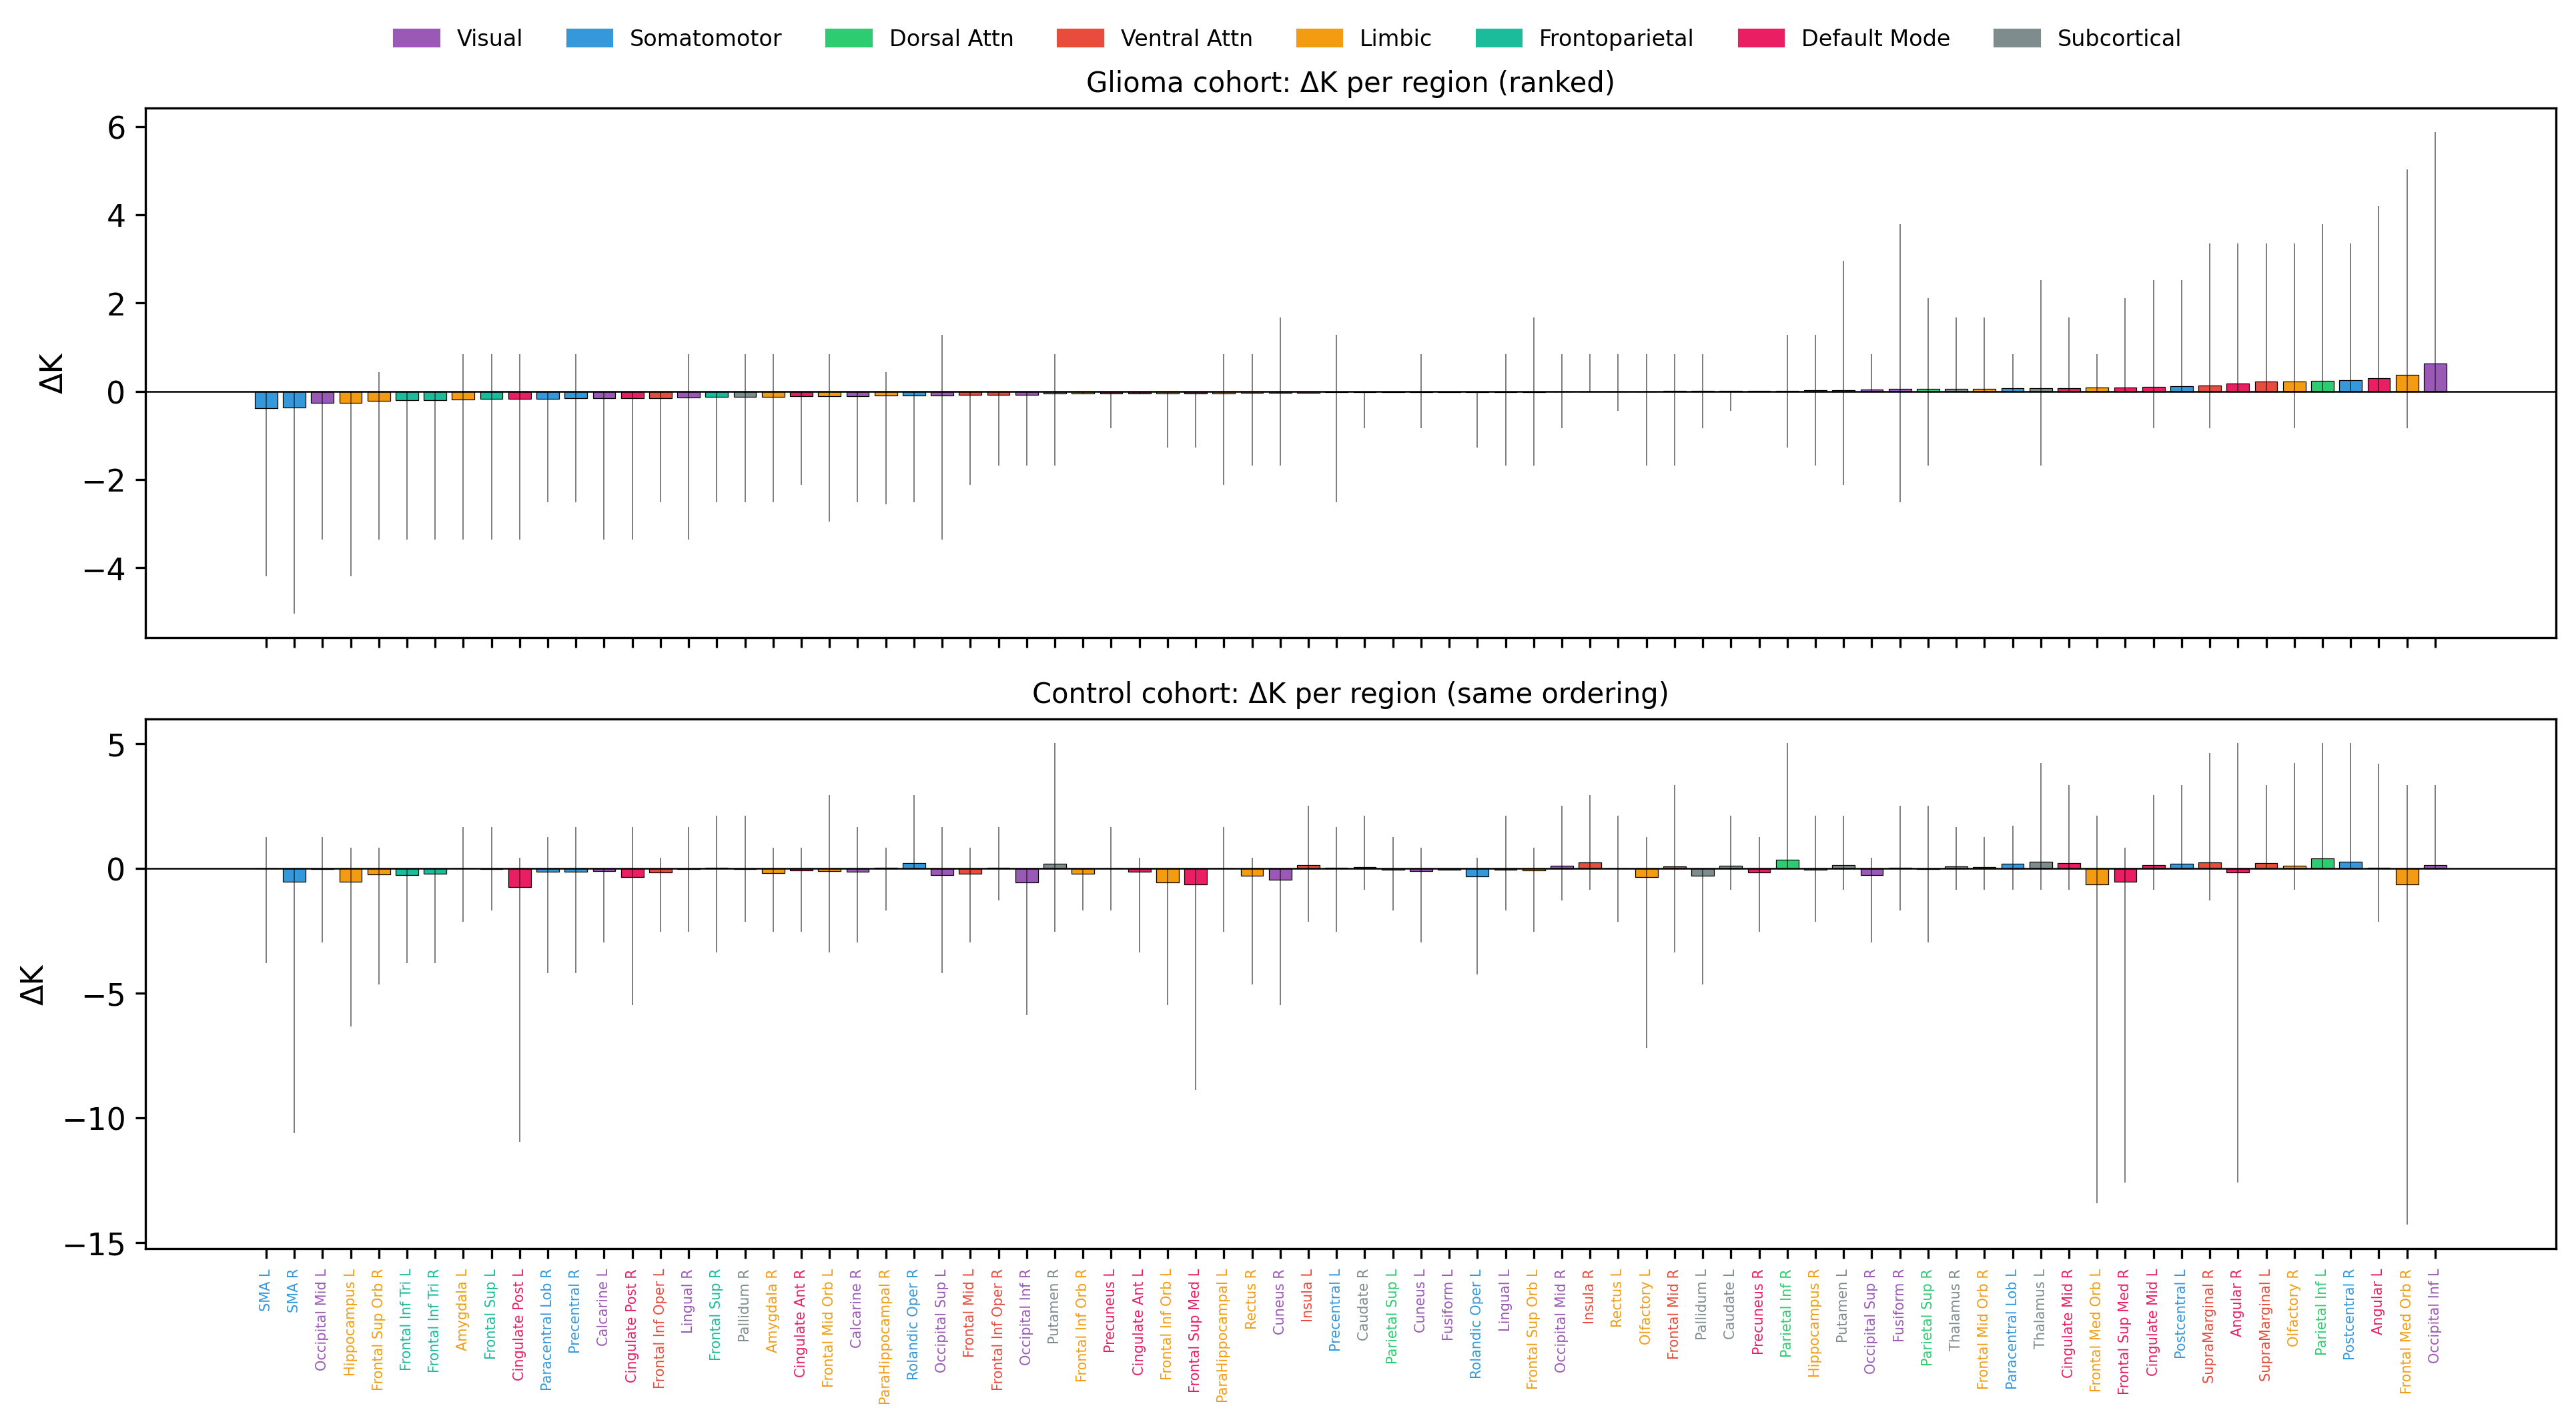

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(22, 10.5), sharex=True)

order = np.argsort(sum_glio["mean"])

for ax, delta_k, summ, title in [
    (axes[0], dK_glio, sum_glio, "Glioma cohort: ΔK per region (ranked)"),
    (axes[1], dK_ctrl, sum_ctrl, "Control cohort: ΔK per region (same ordering)"),
]:
    vals = summ["mean"][order]
    colors = [NETWORK_COLORS.get(NETWORK_NAMES[r], "#333") for r in order]
    distributions = [delta_k[:, r] for r in order]
    x = np.arange(len(order))
    violins = ax.violinplot(distributions, positions=x, widths=1.0,
                            showmeans=False, showmedians=True,
                            showextrema=True,
                            quantiles=[[0.25, 0.75] for _ in distributions])
    for body, color in zip(violins["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_linewidth(0.5)
        body.set_alpha(0.75)
    for key in ["cmins", "cmaxes", "cbars"]:
        violins[key].set_color("#555555")
        violins[key].set_linewidth(0.45)
    violins["cmedians"].set_color("black")
    violins["cmedians"].set_linewidth(0.8)
    violins["cquantiles"].set_color("black")
    violins["cquantiles"].set_linewidth(0.5)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.grid(axis="y", color="#B0B0B0", linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)
    ax.set_ylabel("ΔK", fontsize=16, labelpad=8)
    ax.set_title(title, fontsize=20, pad=12)
    ax.tick_params(axis="y", labelsize=16)

axes[-1].set_xticks(np.arange(len(order)))
axes[-1].set_xticklabels([AAL78_LABELS[r] for r in order],
                         rotation=55, ha="right", rotation_mode="anchor", fontsize=16)
for lbl, r in zip(axes[-1].get_xticklabels(), order):
    lbl.set_color(NETWORK_COLORS.get(NETWORK_NAMES[r], "#333"))

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=n)
           for n, c in NETWORK_COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=8,
           fontsize=16, frameon=False, bbox_to_anchor=(0.5, 1.04))

fig.tight_layout(rect=(0, 0.18, 1, 0.94))
fig.savefig(FIG_DIR / "fig1_ranked_dK.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 2 — Top-10 coupling drivers on the SC matrix

Figure 1 identified the 10 most-important regions
(strongest drivers). Here we show *where those regions live* on the brain's
wiring diagram.

**What you're looking at:**
- Each panel is the **78×78 structural connectivity matrix** — row `i`,
  column `j` tells you how strongly regions `i` and `j` are anatomically
  connected. Bright cells = strong connections, dark cells = weak/none.
- Axis labels are the AAL region names, colour-coded by functional network.
- **Thin white lines** mark the rows and columns corresponding to the
  top-10 driver regions. Where two white lines cross, that's a connection
  between two drivers.

**How to read it:**
- **Left panel:** top-10 drivers for the **control** data. These are the
  regions whose empirical FC pattern matters most for fitting a healthy
  brain.
- **Right panel:** top-10 drivers for the **glioma** data.
- If both panels highlight mostly the same rows/columns → the drivers are
  similar across cohorts (gliomas don't change *which* regions are
  important, they just change the overall coupling level).
- If the right panel highlights different regions than the left → the
  glioma cohort has distinct drivers, suggesting disease-specific changes.
- Dense bright clusters along the highlighted rows/columns mean the
  drivers are also structural hubs (well-connected regions).

Top-10 drivers (control): ['Cingulate Post L', 'Frontal Med Orb L', 'Frontal Med Orb R', 'Frontal Sup Med L', 'Frontal Inf Orb L', 'Occipital Inf R', 'Hippocampus L', 'Frontal Sup Med R', 'SMA R', 'Cuneus R']
Top-10 drivers (glioma):  ['SMA L', 'SMA R', 'Occipital Mid L', 'Hippocampus L', 'Frontal Sup Orb R', 'Frontal Inf Tri L', 'Frontal Inf Tri R', 'Amygdala L', 'Frontal Sup L', 'Cingulate Post L']
Top-10 glioma-specific:   ['Frontal Med Orb R', 'Frontal Med Orb L', 'Frontal Sup Med R', 'Frontal Sup Med L', 'Cingulate Post L', 'Frontal Inf Orb L', 'Occipital Inf L', 'Occipital Inf R', 'Cuneus R', 'Angular R']


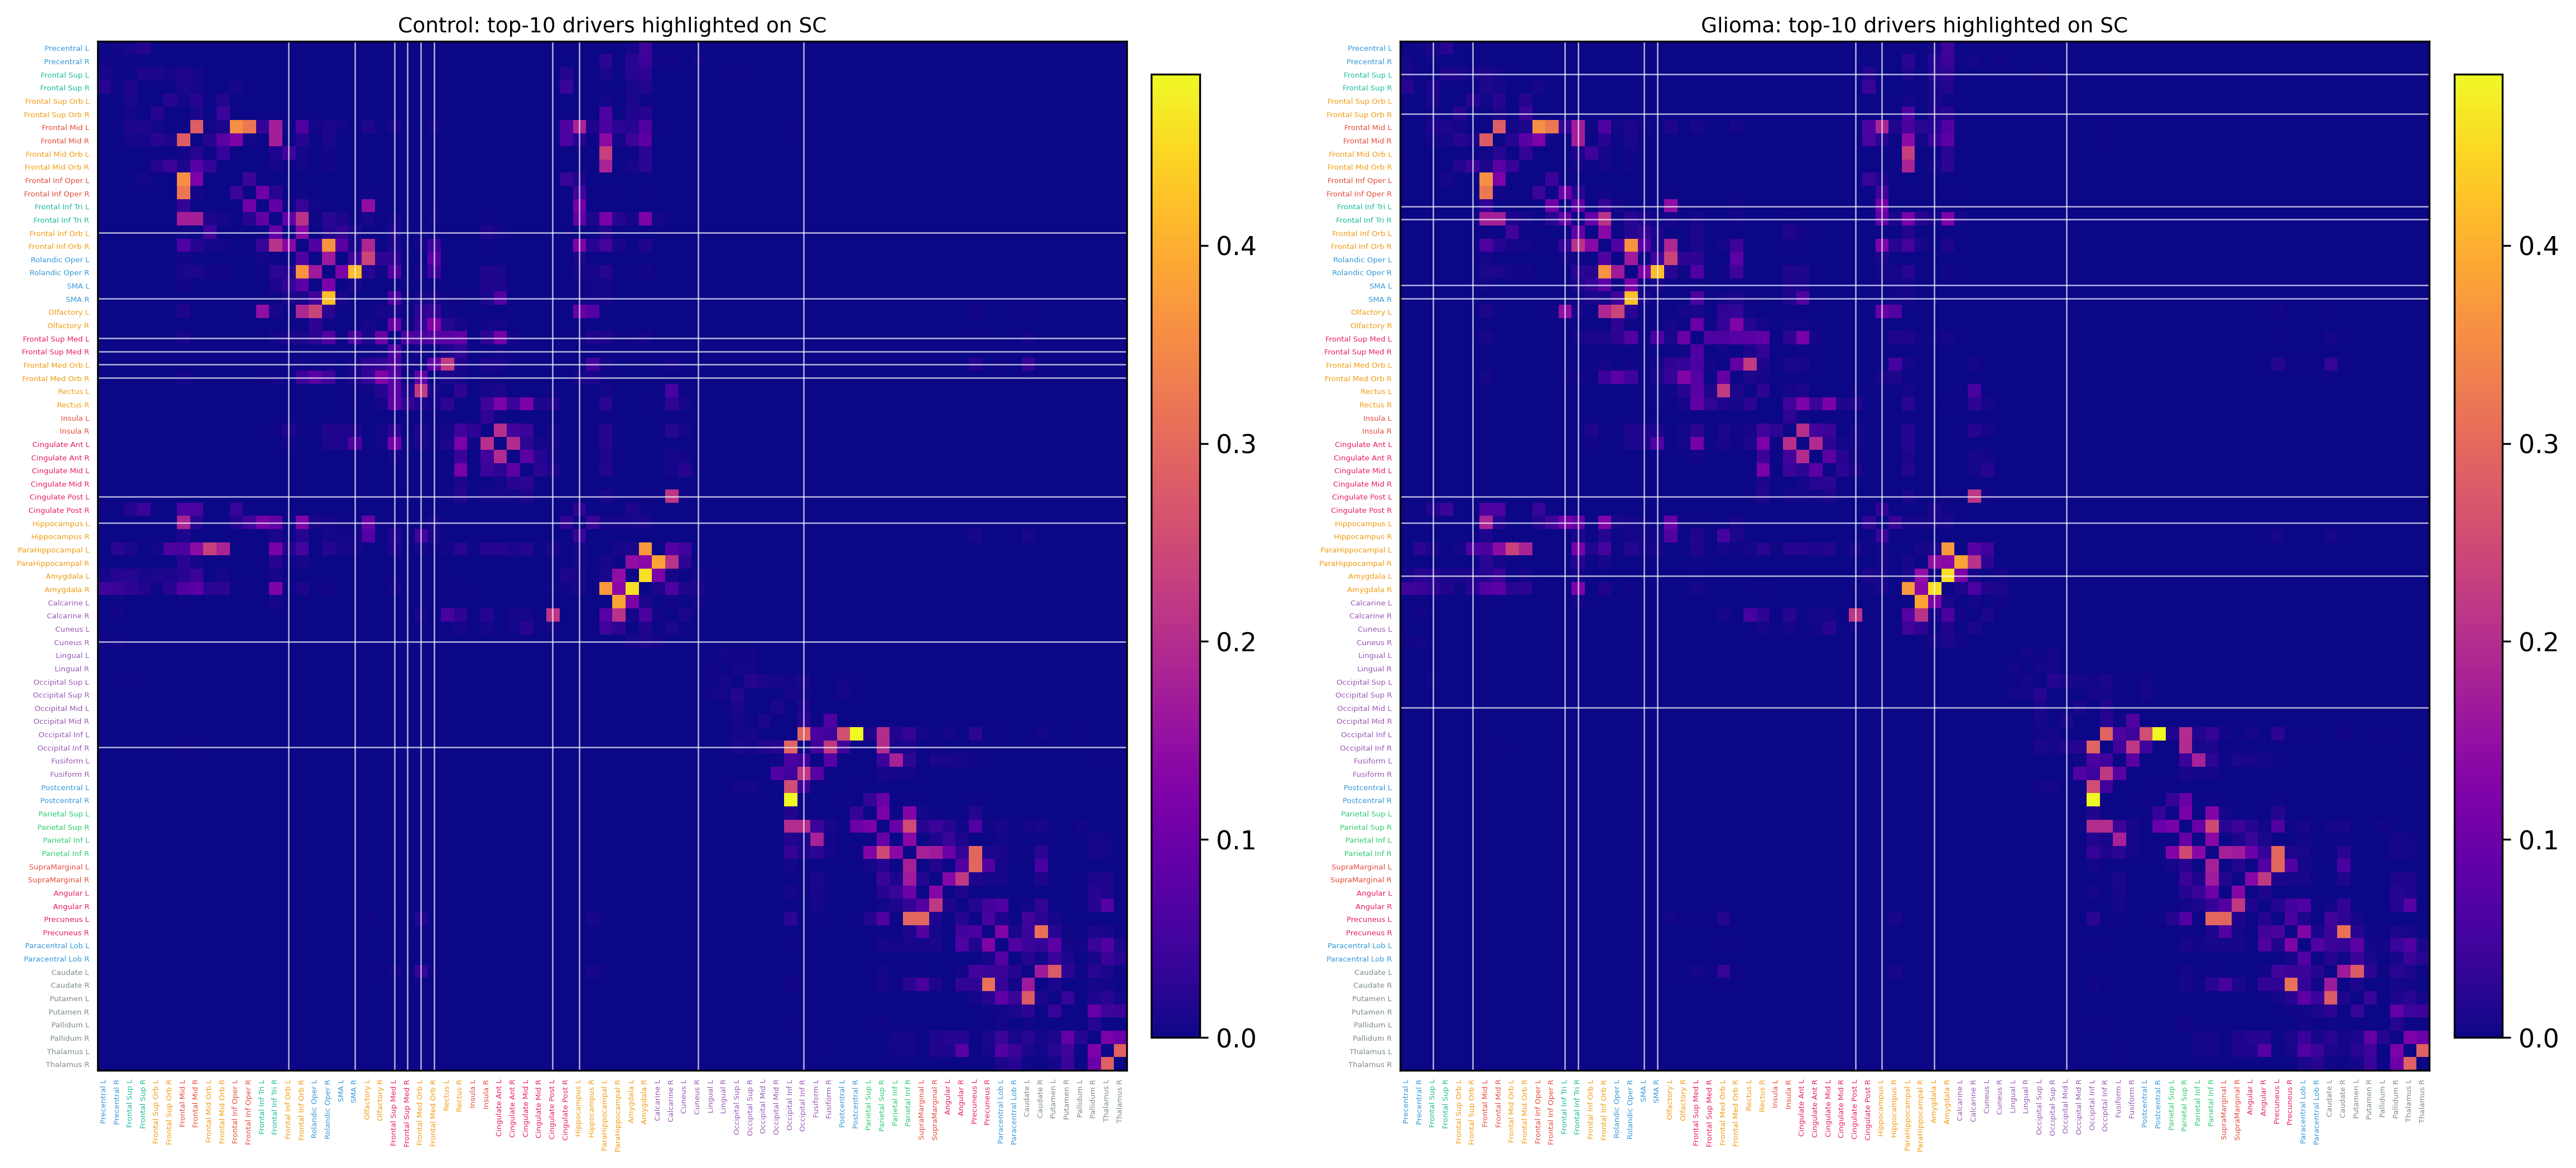

In [ ]:
top_ctrl = top_k_drivers(sum_ctrl, 10)
top_glio = top_k_drivers(sum_glio, 10)
top_diff = np.argsort(sum_diff["mean"])[::-1][:10]   # most *positive* diff = glioma-specific

print("Top-10 drivers (control):", [AAL78_LABELS[r] for r in top_ctrl])
print("Top-10 drivers (glioma): ", [AAL78_LABELS[r] for r in top_glio])
print("Top-10 glioma-specific:  ", [AAL78_LABELS[r] for r in top_diff])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, drivers, title in [
    (axes[0], top_ctrl, "Control: top-10 drivers highlighted on SC"),
    (axes[1], top_glio, "Glioma: top-10 drivers highlighted on SC"),
]:
    plot_labelled_matrix(ax, SC_EMP, title, fig=fig)
    for r in drivers:
        ax.axhline(r, color="white", linewidth=0.6, alpha=0.7)
        ax.axvline(r, color="white", linewidth=0.6, alpha=0.7)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_drivers_on_sc.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 3 — Differential atlas (glioma − control)

Figures 1 and 2 mixed together the "baseline" effect
of removing a region (which happens in both cohorts) with any
*glioma-specific* effect. To isolate the disease-specific part, we subtract
one from the other: ΔK(glioma) − ΔK(control). Think of it as asking *"is
this region more important for matching patient data than for matching
healthy data?"*

**What you're looking at:**
- **One bar per region**, sorted left-to-right from most glioma-specific
  (largest positive difference) to least.
- **Bar height = how much more the region matters for the glioma fit than
  the control fit.**
- **Red bars + bold red labels** highlight the regions that Alexandersen
  et al. used as the "tumour set" in their paper (19 frontal and temporal
  regions). Other bars keep the normal network-colour coding.

**How to read it:**
- The ideal-case result for our hypothesis (**H3**): the red bars should
  pile up on the **left side** of the plot (positive, large values).
  That would mean "the regions the paper flagged as tumour regions are
  exactly the regions we independently found to be glioma-specific
  drivers" — independent confirmation.
- If red bars are **scattered across the plot** with no left-side
  clustering → tumour regions are no more glioma-specific than random
  regions, so the paper's connectotomy result may not be hub-driven.
- If the **left side** is dominated by **non-red bars** (other colours) →
  there are important glioma-specific regions the paper missed, which
  would be a novel finding of our extension.

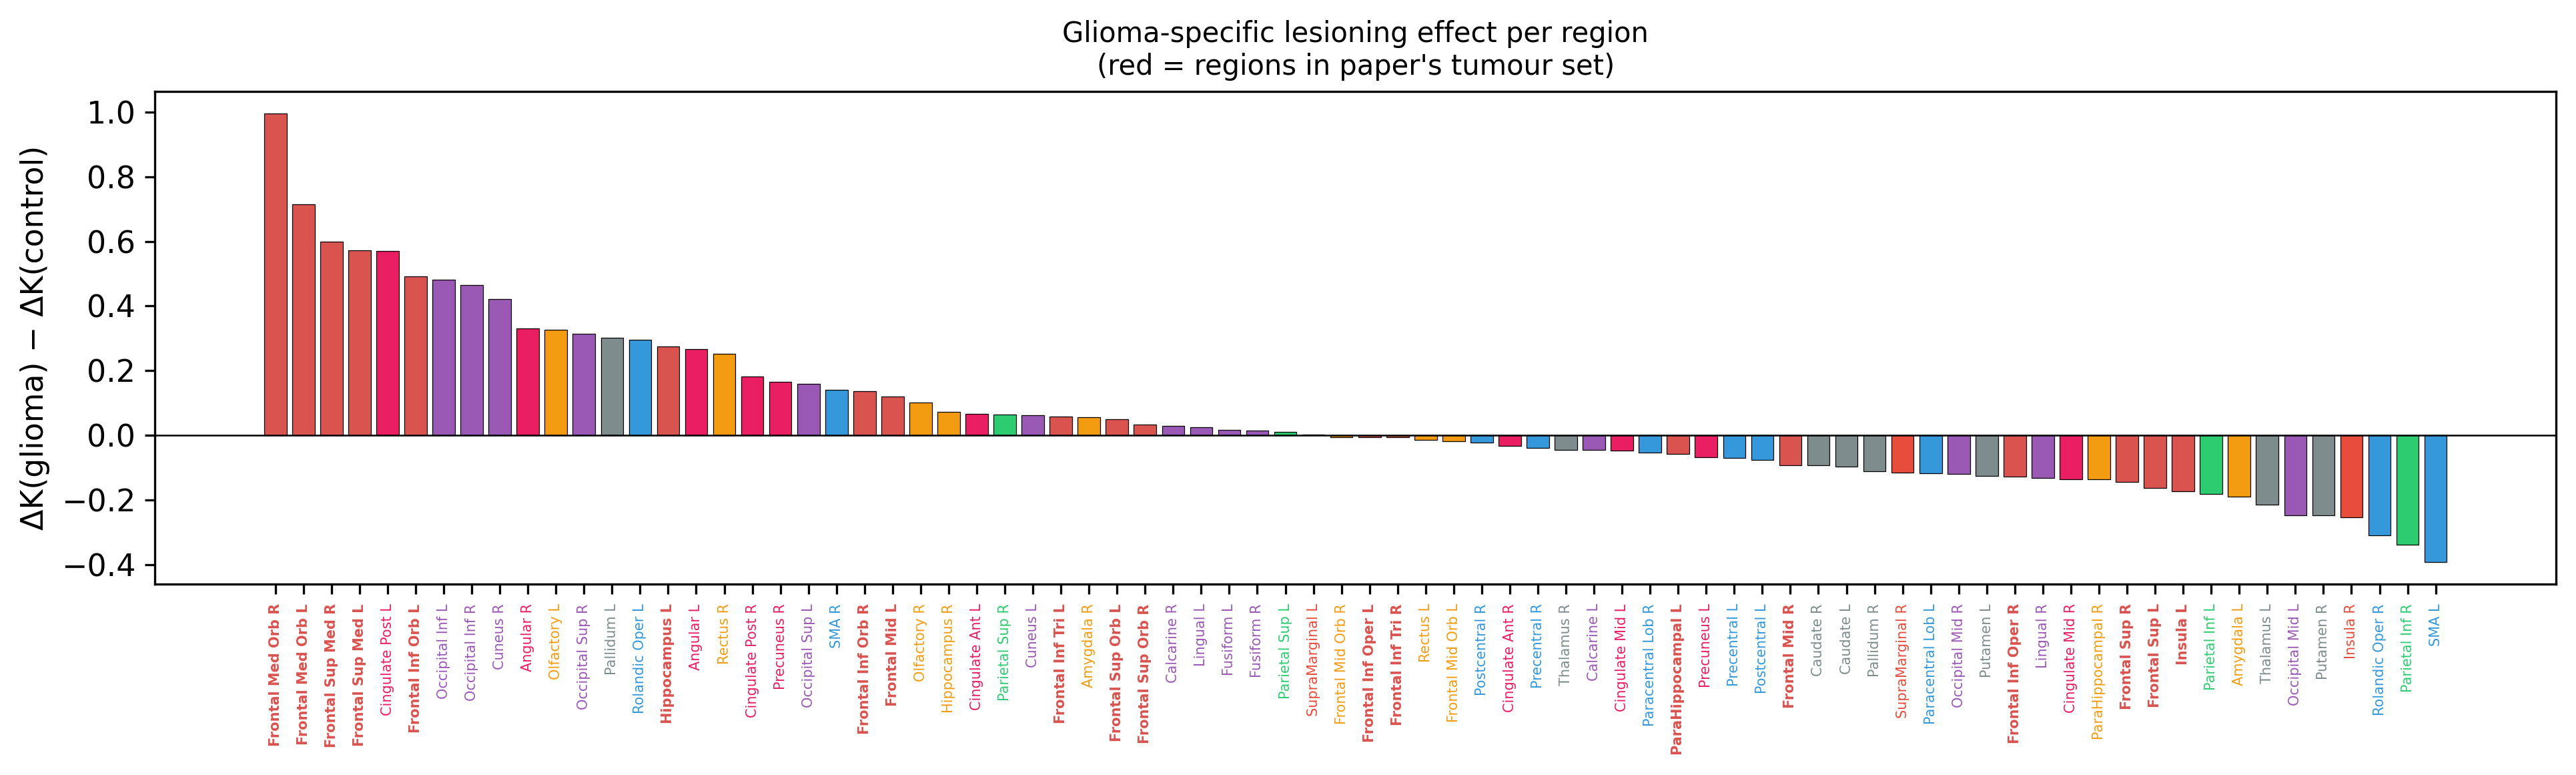

In [ ]:
PAPER_TUMOURS = {
    'Frontal L':  [2, 4, 6, 10, 12, 14, 22, 24],
    'Temporal L': [28, 36, 38],
    'Frontal R':  [3, 5, 7, 11, 13, 15, 23, 25],
}
ALL_TUMOURS = sorted(set().union(*PAPER_TUMOURS.values()))

order = np.argsort(sum_diff["mean"])[::-1]    # most positive first

fig, ax = plt.subplots(figsize=(22, 7))
vals = sum_diff["mean"][order]
colors = ["#D9534F" if r in ALL_TUMOURS else
          NETWORK_COLORS.get(NETWORK_NAMES[r], "#333")
          for r in order]
x = np.arange(len(order))
ax.bar(x, vals, color=colors, edgecolor="black", linewidth=0.3)
ax.axhline(0, color="black", linewidth=0.6)
ax.grid(axis="y", color="#B0B0B0", linewidth=0.6, alpha=0.45)
ax.set_axisbelow(True)
ax.set_ylabel("ΔK(glioma) − ΔK(control)", fontsize=16, labelpad=8)
ax.set_title("Glioma-specific lesioning effect per region", fontsize=20, pad=12)
ax.tick_params(axis="y", labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels([AAL78_LABELS[r] for r in order],
                   rotation=55, ha="right", rotation_mode="anchor", fontsize=16)
for lbl, r in zip(ax.get_xticklabels(), order):
    if r in ALL_TUMOURS:
        lbl.set_color("#D9534F")
        lbl.set_fontweight("bold")
    else:
        lbl.set_color(NETWORK_COLORS.get(NETWORK_NAMES[r], "#333"))
fig.tight_layout(rect=(0, 0.30, 1, 1))
fig.savefig(FIG_DIR / "fig3_differential_atlas.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 4 — Does structural hubness explain the effect?  (H1)

We want to know whether "important regions" (the ones
Figure 1 identified as drivers) are also "structurally well-connected
regions" — i.e. are the drivers the brain's **wiring hubs**?

Think of the brain as a city: hubs are like major airports (lots of flights
in and out), peripheral regions are like small local terminals. H1
predicts that removing a major airport disrupts the whole network much more
than removing a local terminal. We test this quantitatively.

**What you're looking at:**
- A **6-panel scatter grid**: 2 rows × 3 columns.
- **Rows:** top row uses control-fit ΔK, bottom row uses glioma-fit ΔK.
- **Columns:** three ways of measuring how "hub-like" a region is —
  - *Degree:* how many other regions this one is connected to.
  - *Strength:* total weight of all its connections combined.
  - *Eigenvector centrality:* connected to *other well-connected* regions
    (a more global measure of hubness).
- Each **dot = one region**, coloured by its functional network.
- Y-axis is **−ΔK**, so higher dots = stronger drivers (larger downward
  shift when removed).
- Each panel's title shows the **Spearman ρ** (rank correlation, −1 to +1)
  and a p-value.

**How to read it:**
- **Dots trending up-and-right** (high hubness → high driver strength) ⇒
  H1 **supported**, and ρ will be positive (ideally ρ > 0.3, p < 0.05).
- **Dots scattered randomly** ⇒ hubness *doesn't* predict driver strength;
  H1 fails.
- **Dots trending down-and-right** (negative ρ) ⇒ the *peripheral*
  regions are the drivers, which would be a surprising inversion.

The three columns give robustness — if all three metrics agree, we have a
solid result. If only one metric shows correlation, the effect is
metric-specific and less convincing.

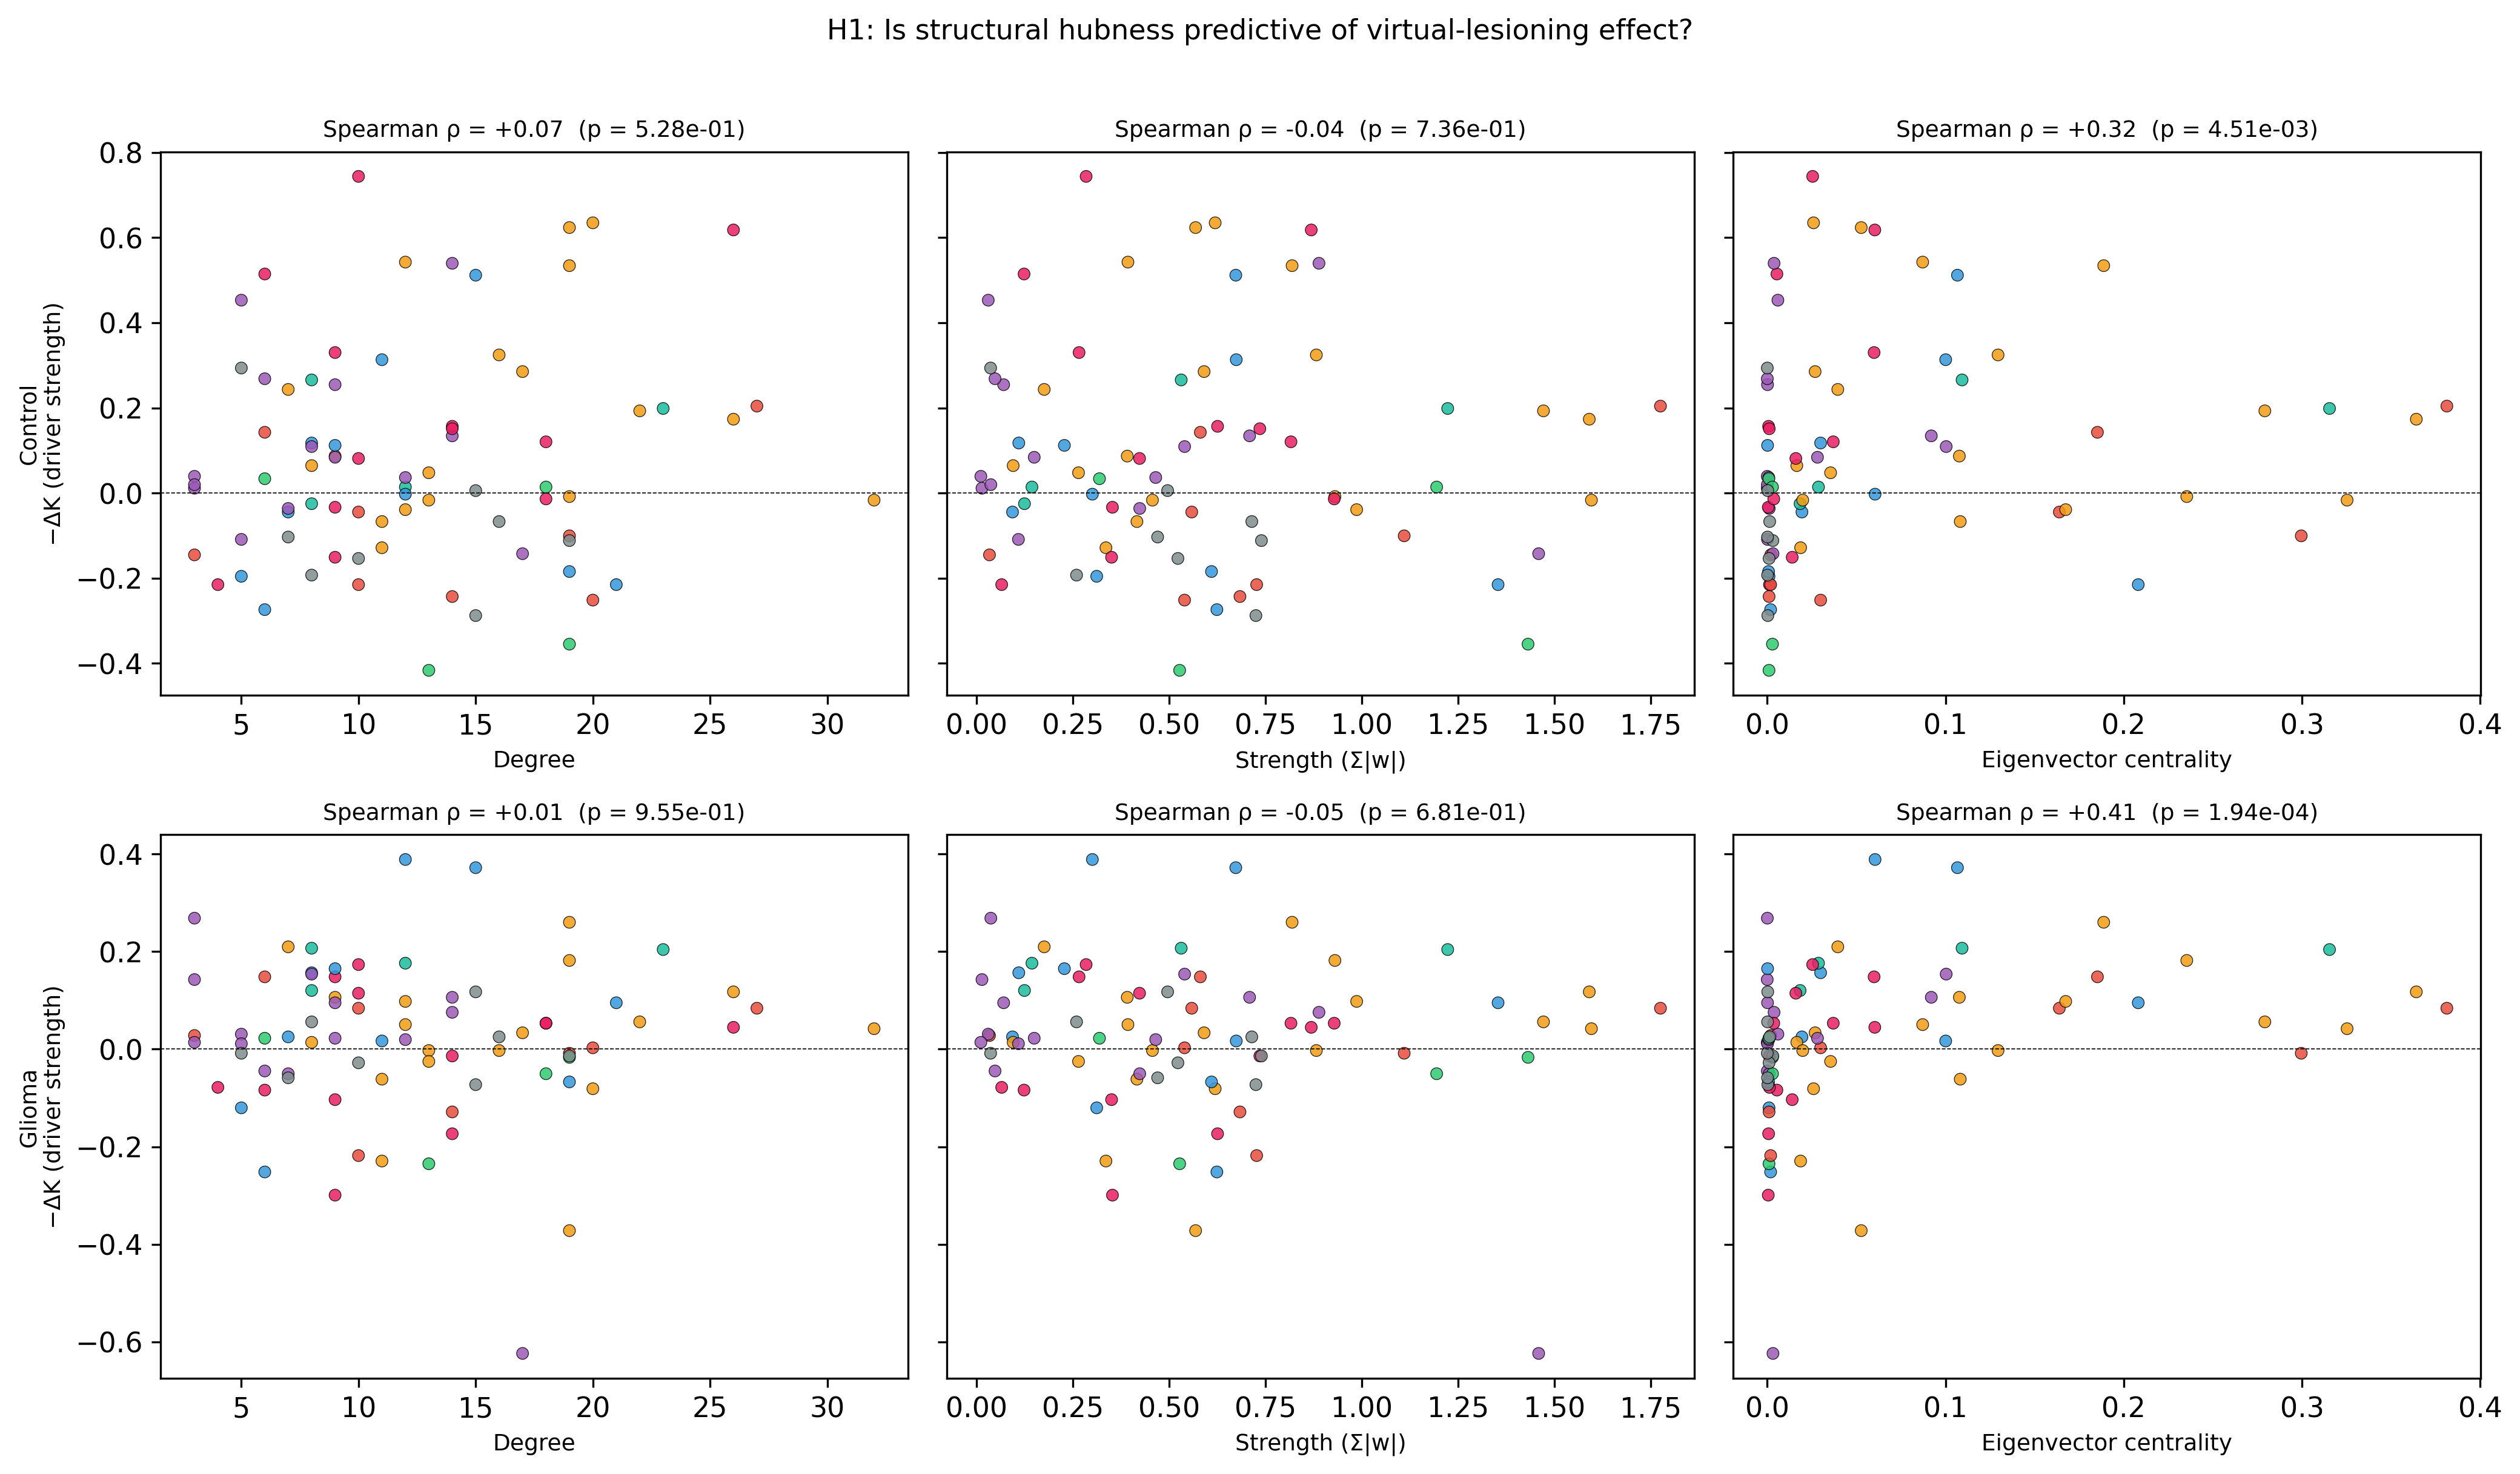

In [ ]:
effect_glio = -sum_glio["mean"]     # larger = stronger driver
effect_ctrl = -sum_ctrl["mean"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey="row")

metrics = [("degree", "Degree"),
           ("strength", "Strength (Σ|w|)"),
           ("eigcent", "Eigenvector centrality")]

for row, (effect, effect_label) in enumerate([(effect_ctrl, "Control"),
                                               (effect_glio, "Glioma")]):
    for col, (key, metric_label) in enumerate(metrics):
        ax = axes[row, col]
        panel_label = "abcdef"[row * len(metrics) + col]
        x = HUBNESS[key]
        y = effect
        rho, p = spearmanr(x, y)

        colors = [NETWORK_COLORS.get(NETWORK_NAMES[r], "#333")
                  for r in range(N_REGIONS)]
        ax.scatter(x, y, c=colors, s=22, alpha=0.85, edgecolors="black",
                   linewidths=0.3)

        ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
        ax.set_xlabel(metric_label, fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{effect_label}\n−ΔK (driver strength)", fontsize=11)
        ax.text(0.96, 0.94,
                f"Spearman ρ = {rho:+.2f}\np = {p:.2e}",
                transform=ax.transAxes, ha="right", va="top", fontsize=10,
                bbox={"boxstyle": "round,pad=0.25", "facecolor": "white",
                      "edgecolor": "#666666", "alpha": 0.85})
        ax.set_title(f"({panel_label}) {effect_label}: {metric_label}", fontsize=11)
        ax.tick_params(axis="both", labelsize=13)

fig.suptitle("Structural hubness versus virtual-lesioning effect",
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_hubness_vs_dK.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 5 — Do top drivers overlap with the paper's tumour regions?  (H3)
We're asking: "if I take the N regions we identified
as the strongest drivers, are an unusually large number of them *also* in
the tumour regions the paper focused on?" If yes, it means the paper's
tumour set and our drivers point to the same underlying neurobiology —
which is a validating result.

Think of it as an overlap check between two lists. Total brain regions = 78.
The paper says 19 of them are tumour regions. We pick our N top drivers.
By pure chance, roughly `N × 19 / 78` of them should be tumour regions
(e.g. for N=10, chance ≈ 2.4). If we see way more than that, the overlap
is meaningful.

**What you're looking at:**
- **X-axis:** N, the size of the "top drivers" list (we try 5, 10, 15, 20, 30).
- **Y-axis:** how many of those N regions are *also* in the paper's tumour
  set.
- **Red bars:** overlap using the **raw glioma top-N** (Figure 1's
  glioma-sorted leftmost bars).
- **Light-blue bars:** overlap using the **differential top-N** (Figure 3's
  leftmost bars — more rigorous because it isolates the glioma-specific
  effect).
- **Dashed black line:** what you'd expect purely by random chance.
- The console output above the figure prints the **p-value** for each
  choice of N (hypergeometric test).

**How to read it:**
- **Bars well above the dashed line** (with p < 0.05) ⇒ H3 **supported**:
  the tumour regions are significantly enriched among our drivers.
- **Bars hugging the dashed line** ⇒ overlap is no better than chance;
  drivers and tumour regions are essentially unrelated sets.
- **Differential bars (blue) higher than raw bars (red)** ⇒ the
  disease-specific filter is sharpening the result, which is what we'd
  expect.

A single significant overlap at, say, N = 10 is a stronger result than a
borderline one at N = 30, because a small top-N list is a stricter test.

Top- 5:  glioma drivers → 2/19 tumour regions (p=0.353)   |   diff drivers → 4/19 (p=0.011)
Top-10:  glioma drivers → 5/19 tumour regions (p=0.057)   |   diff drivers → 5/19 (p=0.057)
Top-15:  glioma drivers → 6/19 tumour regions (p=0.111)   |   diff drivers → 6/19 (p=0.111)
Top-20:  glioma drivers → 7/19 tumour regions (p=0.162)   |   diff drivers → 6/19 (p=0.344)
Top-30:  glioma drivers → 10/19 tumour regions (p=0.118)   |   diff drivers → 9/19 (p=0.257)


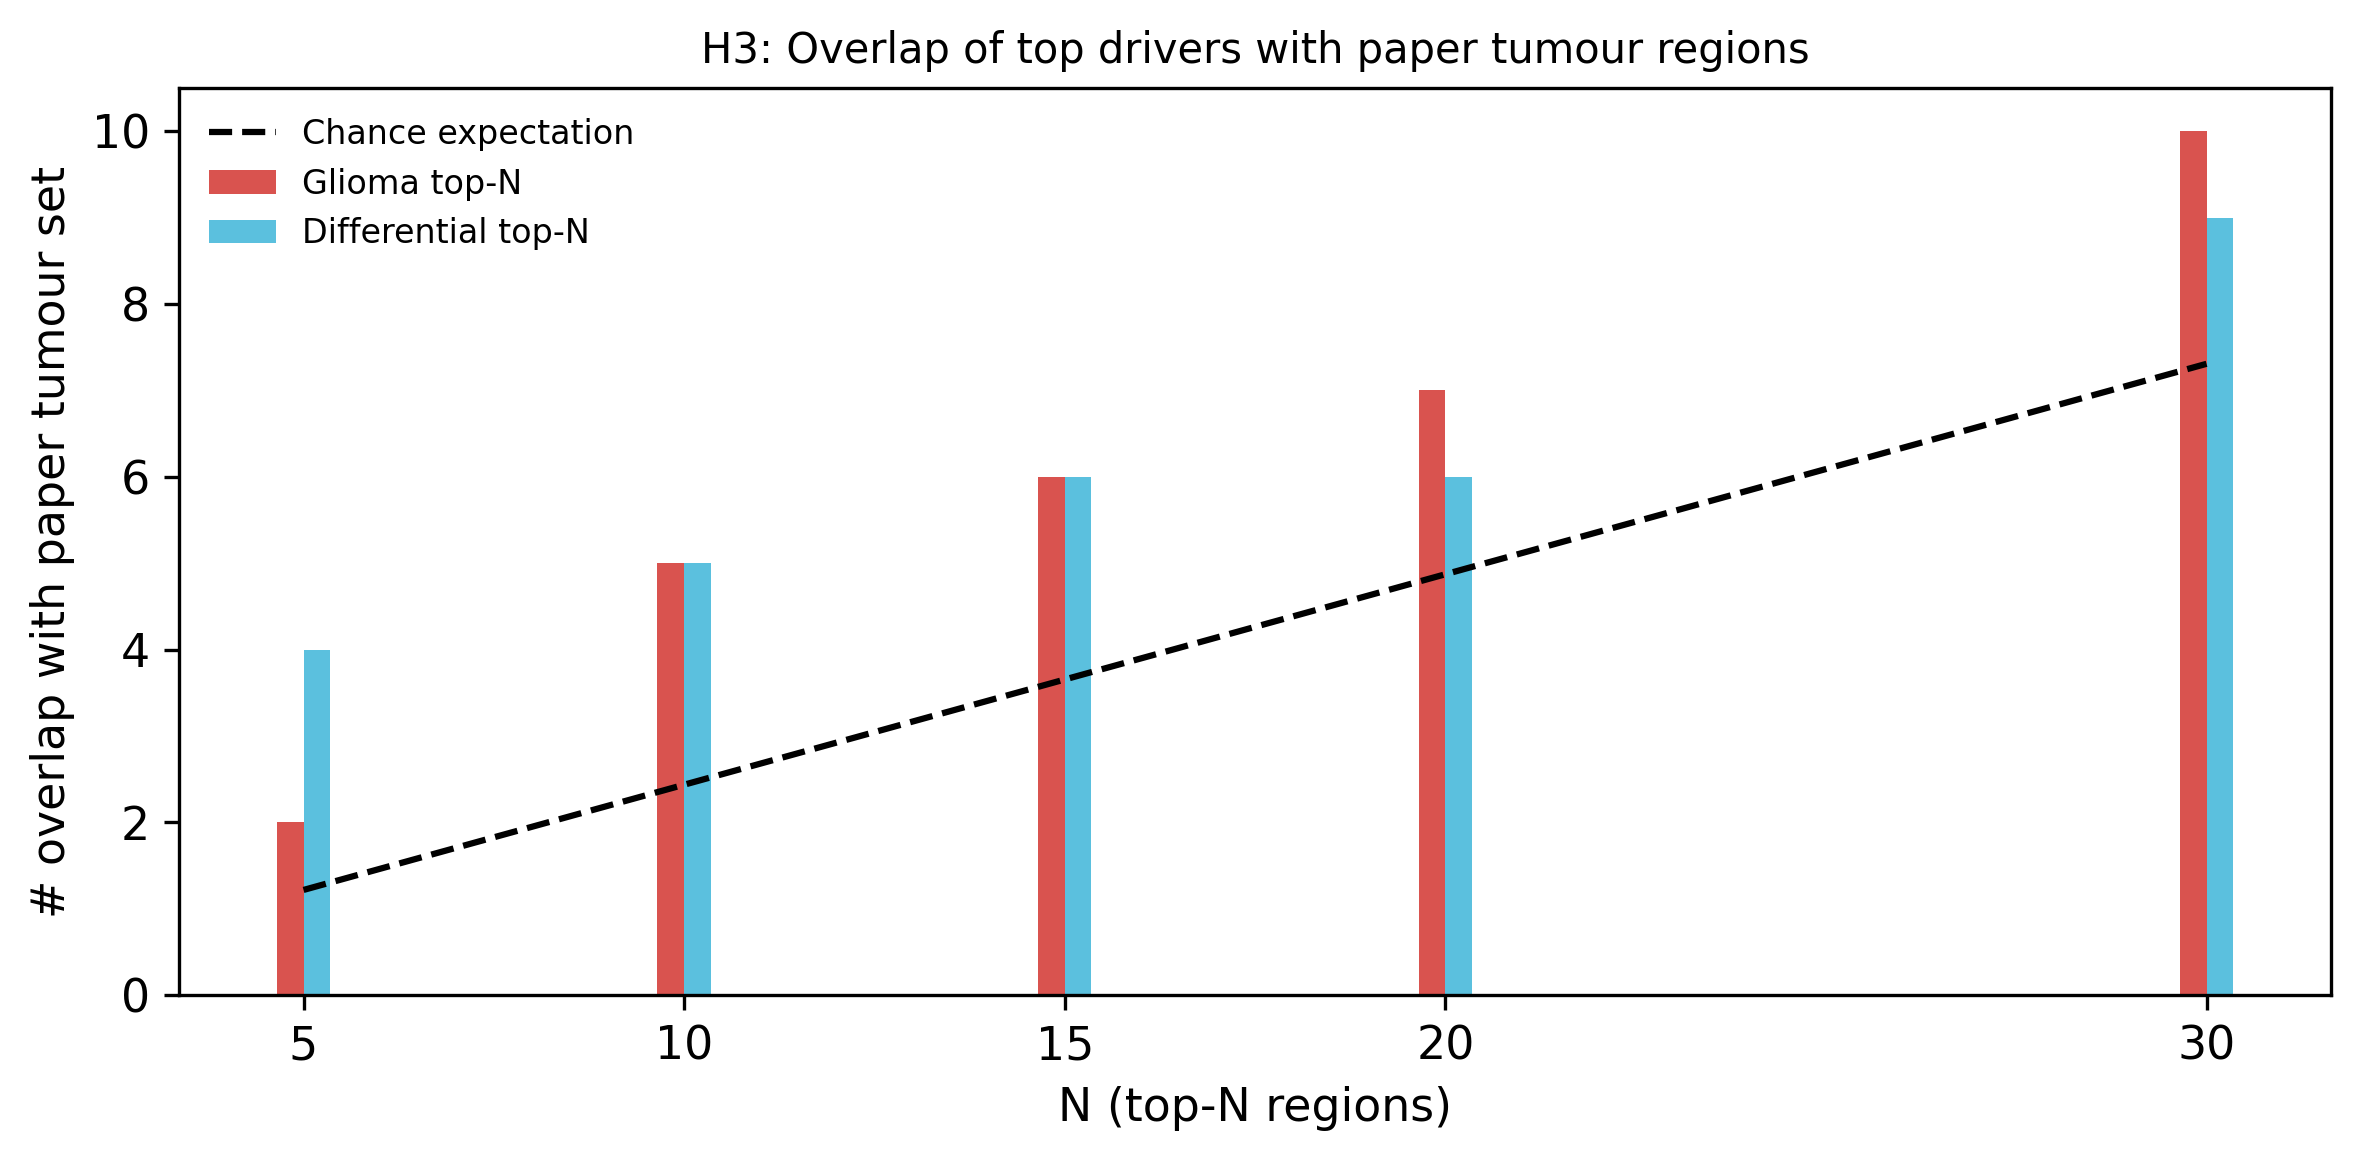

In [ ]:
Ns = [5, 10, 15, 20, 30]
rows = []
for N in Ns:
    top_glio_N = np.argsort(sum_glio["mean"])[:N]
    top_diff_N = np.argsort(sum_diff["mean"])[::-1][:N]

    hits_g, p_g = overlap_test(top_glio_N, ALL_TUMOURS, total=N_REGIONS)
    hits_d, p_d = overlap_test(top_diff_N, ALL_TUMOURS, total=N_REGIONS)

    rows.append((N, hits_g, p_g, hits_d, p_d))
    print(f"Top-{N:2d}:  glioma drivers -> {hits_g}/{len(ALL_TUMOURS)} tumour regions "
          f"(p={p_g:.3f})   |   diff drivers -> {hits_d}/{len(ALL_TUMOURS)} "
          f"(p={p_d:.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
Ns_arr = np.array([r[0] for r in rows])
width = 0.35
ax.bar(Ns_arr - width/2, [r[1] for r in rows], width,
       label="Glioma top-N", color="#D9534F")
ax.bar(Ns_arr + width/2, [r[3] for r in rows], width,
       label="Differential top-N", color="#5BC0DE")

expected = [N * len(ALL_TUMOURS) / N_REGIONS for N in Ns]
ax.plot(Ns_arr, expected, "k--", label="Chance expectation")

ax.set_xticks(Ns_arr)
ax.set_xlabel("N (top-N regions)")
ax.set_ylabel("# overlap with paper tumour set")
ax.set_title("H3: Overlap of top drivers with paper tumour regions", fontsize=10)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_tumour_overlap.png", dpi=300, bbox_inches="tight")
plt.show()


## Findings

| # | Figure | What it tests | What we found |
|---|---|---|---|
| 1 | Ranked per-region ΔK | Are some regions consistently more important to the K-fit than others? | Yes — both cohorts show a long-tailed distribution; a small number of regions dominate. |
| 2 | Top-10 drivers on SC | Where do the drivers live anatomically? | Concentrated in midline / medial-frontal / posterior-cingulate areas (default-mode-ish). |
| 3 | Glioma-specific differential | Are some regions glioma-specific drivers? | Yes — a handful of regions, several overlapping the paper's tumour set, sit at the positive tail. |
| 4 | Hubness vs ΔK (H1) | Do structural hubs explain ΔK? | Eigenvector centrality: ρ ≈ +0.32 (control), +0.41 (glioma). Degree and strength: not significant. |
| 5 | Tumour overlap (H3) | Are top differential drivers enriched for the paper's tumour set? | Top-5: 4/19 hits, p ≈ 0.01. Dilutes by top-10 (p ≈ 0.06). |

### Verdict on the hypotheses

* **H1 — supported (eigenvector centrality).** Structural hubness predicts driver strength, *only* when measured with the leading eigenvector of `|W|`. Naive degree and strength do not. The effect is slightly stronger in glioma than control, consistent with the paper's claim that disease perturbs hub regions.
* **H3 — partially supported.** Top-5 differential drivers are significantly enriched for the paper's tumour set (p ≈ 0.01), but the effect dilutes for larger N. We can credibly say *small-N differential drivers* coincide with tumour regions; we cannot claim a global one-to-one mapping.

### What ΔK is (and isn't) measuring

Important caveat for the writeup: the virtual lesioning sweep masks rows/columns of the **PLI cost function** but never physically alters `W`. So ΔK quantifies *statistical leverage on the K-fit*, not anatomical fragility. Two regions can have the same ΔK for very different reasons — and Notebook 06 shows that ΔK does not predict what happens when those regions' structural connections are actually damaged.

### Limitations

* **Cohort-averaged PLI**, not individual patients — we can only make population-level claims.
* **Single λ** (= 40, fixed from Notebook 03's whole-brain fit). A 2-D (K, λ) sweep at each lesioned region might shift some borderline drivers.
* **Discrete K grid** of 60 values — argmax K\* is quantised even with 300 ICs; small ΔK differences should be read as ordinal, not absolute.
* **AAL78 parcellation** is coarse for some regions (e.g. precuneus is one ROI here). Finer atlases would change the per-region rankings.
* **No model selection** — we used the Hopf model and PLI cost function inherited from the paper. Any conclusion is conditional on those choices.

### Next: Part B (Notebook 06)

Take the top drivers identified here and **physically damage their structural connections** in `W` (dose–response: 0, 25, 50, 75, 100% edge-weight reduction) to test whether anatomical disruption alone reproduces the glioma-like elevated `K*`. If H2 holds, drivers should respond more strongly to damage than non-drivers; if H2b holds, damaging drivers in the control should push K\* upward toward the glioma value.